In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.datasets import load_iris
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage


In [14]:
iris = load_iris()

# Using first two features for visualization

X = iris.data[:, :2]

y = iris.target

print("Dataset Shape:", X.shape)


Dataset Shape: (150, 2)


In [15]:
linkage_methods = [
    "single",
    "complete",
    "average",
    "ward"
]

results = []

models = {}


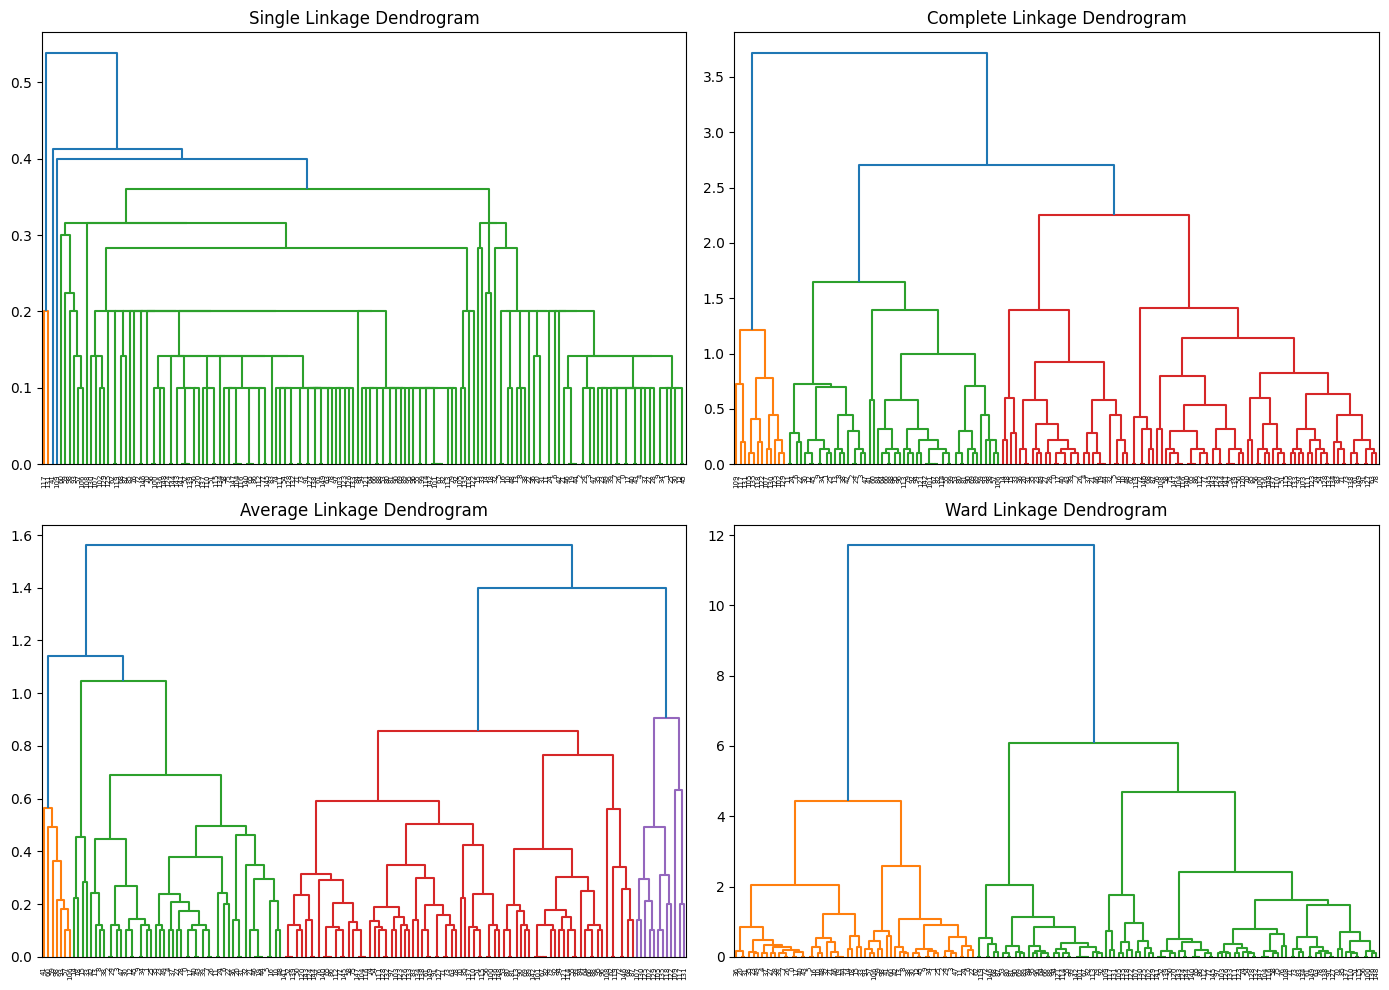

In [16]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(14,10)
)

axes = axes.ravel()

for i, method in enumerate(linkage_methods):

    Z = linkage(
        X,
        method=method
    )

    dendrogram(
        Z,
        ax=axes[i]
    )

    axes[i].set_title(
        f"{method.capitalize()} Linkage Dendrogram"
    )

plt.tight_layout()
plt.show()


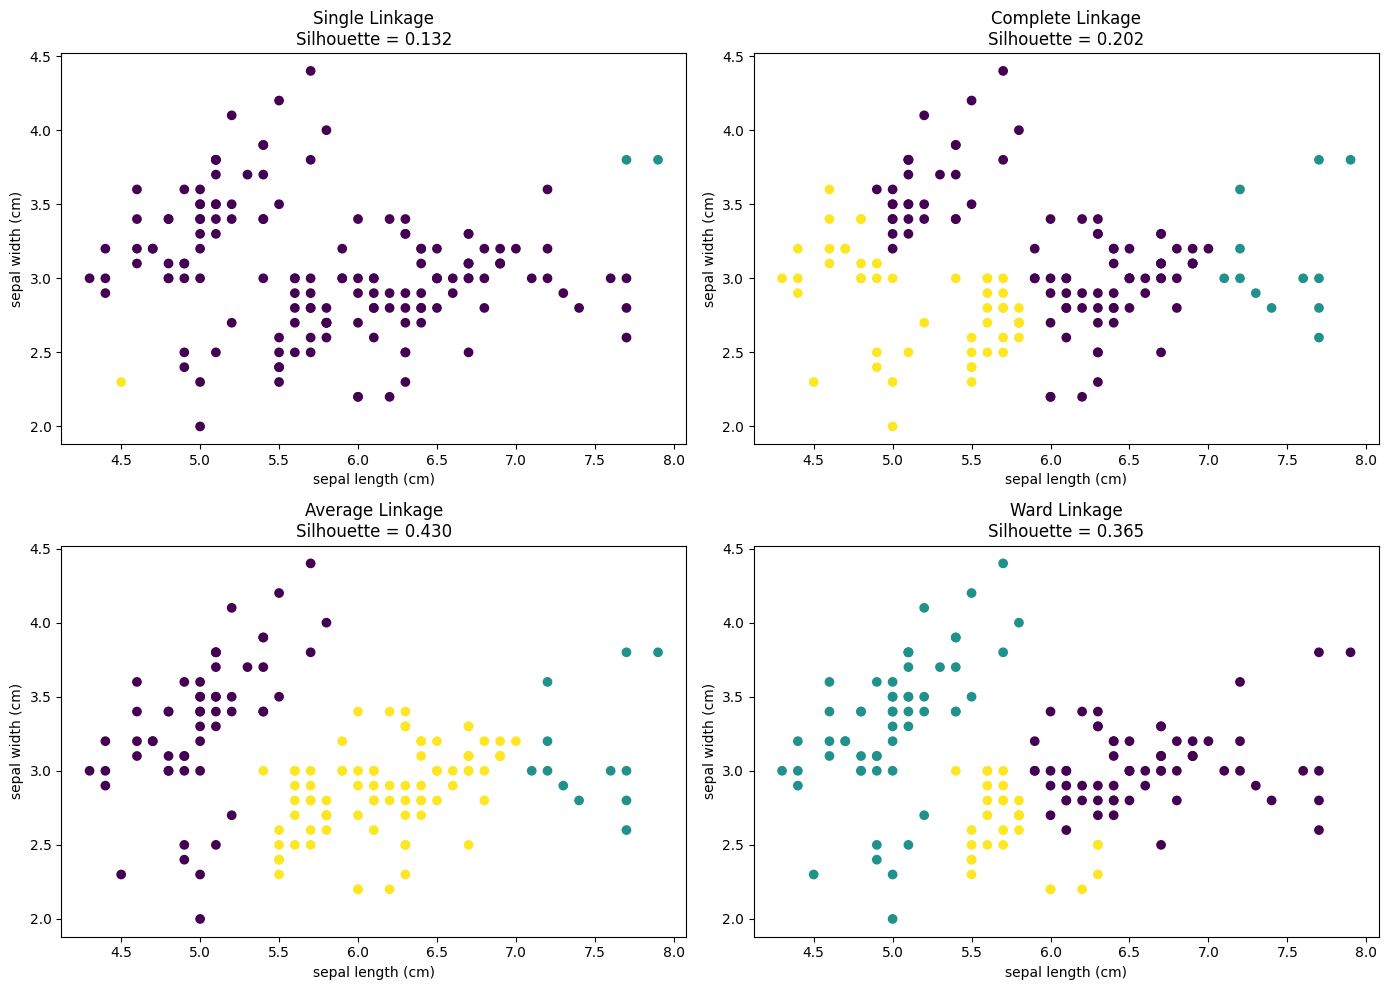

In [17]:

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14,10)
)

axes = axes.ravel()

for i, method in enumerate(linkage_methods):

    model = AgglomerativeClustering(
        n_clusters=3,
        linkage=method
    )

    labels = model.fit_predict(X)

    models[method] = model

    score = silhouette_score(
        X,
        labels
    )

    results.append(
        [method, score]
    )

    axes[i].scatter(
        X[:,0],
        X[:,1],
        c=labels,
        cmap="viridis"
    )

    axes[i].set_title(
        f"{method.capitalize()} Linkage\nSilhouette = {score:.3f}"
    )

    axes[i].set_xlabel(
        iris.feature_names[0]
    )

    axes[i].set_ylabel(
        iris.feature_names[1]
    )

plt.tight_layout()
plt.show()


In [18]:
comparison_df = pd.DataFrame(
    results,
    columns=[
        "Linkage Method",
        "Silhouette Score"
    ]
)

comparison_df = comparison_df.sort_values(
    by="Silhouette Score",
    ascending=False
)

print("\n")
print("="*50)
print("SILHOUETTE SCORE COMPARISON")
print("="*50)

print(comparison_df)



SILHOUETTE SCORE COMPARISON
  Linkage Method  Silhouette Score
2        average          0.430329
3           ward          0.365335
1       complete          0.202303
0         single          0.132065


In [19]:
best_method = comparison_df.iloc[0][
    "Linkage Method"
]

best_model = models[best_method]

print("\nBest Linkage Method:", best_method)


Best Linkage Method: average


In [20]:
joblib.dump(
    best_model,
    "iris_hierarchical_model.pkl"
)

print("\nModel Saved Successfully!")


Model Saved Successfully!


In [21]:
loaded_model = joblib.load(
    "iris_hierarchical_model.pkl"
)

print("Model Loaded Successfully!")

Model Loaded Successfully!


In [22]:
from google.colab import files

files.download(
    "iris_hierarchical_model.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>